# Week 12 - Milestone Two week

# 1. Lesson: no lesson this week.  Milestone Two is due!

# 2. Weekly graph question

Suppose you plot the number visitors to a museum over the seven days of a week; then again the following week.  Can you suggest the advantages and disadvantages of the following two ways of presenting the data?

In [3]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

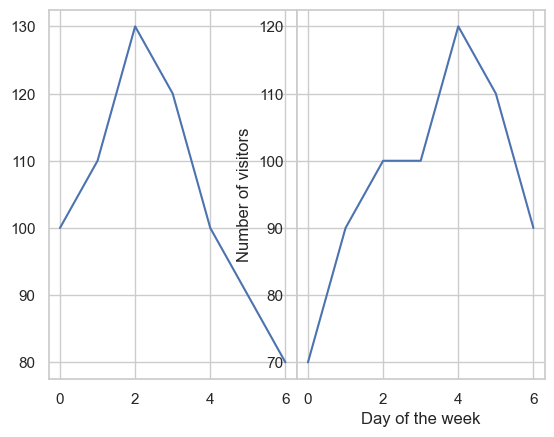

In [4]:
np.random.seed(0)
time_series_0 = np.array([100, 110, 130, 120, 100, 90, 80])
time_series_1 = np.array([70, 90, 100, 100, 120, 110, 90])
fig, axs = plt.subplots(1, 2)
axs[0].plot(time_series_0)
axs[1].plot(time_series_1)
plt.subplots_adjust(wspace = 0)
plt.xlabel("Day of the week");
plt.ylabel("Number of visitors");

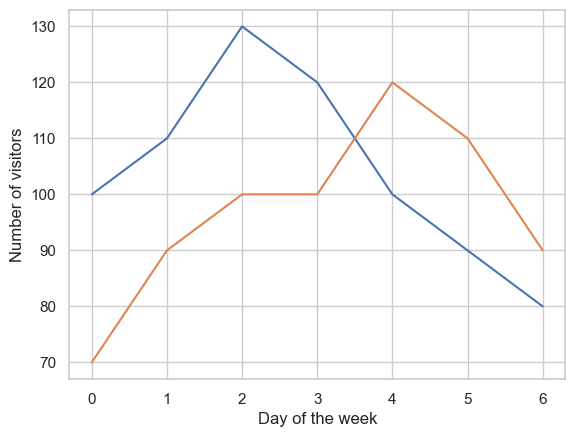

In [5]:
plt.plot(time_series_0)
plt.plot(time_series_1)
plt.xlabel("Day of the week");
plt.ylabel("Number of visitors");

# 3. Working on your datasets

This week, you can work on Milestone Two rather than having a particular exercise about working on your datasets

=== Credit Card Fraud – Baseline Random Forest ===
Accuracy: 0.9995
Precision: 0.9573
Recall: 0.7568
F1: 0.8453
ROC AUC: 0.9307

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.96      0.76      0.85       148

    accuracy                           1.00     85443
   macro avg       0.98      0.88      0.92     85443
weighted avg       1.00      1.00      1.00     85443



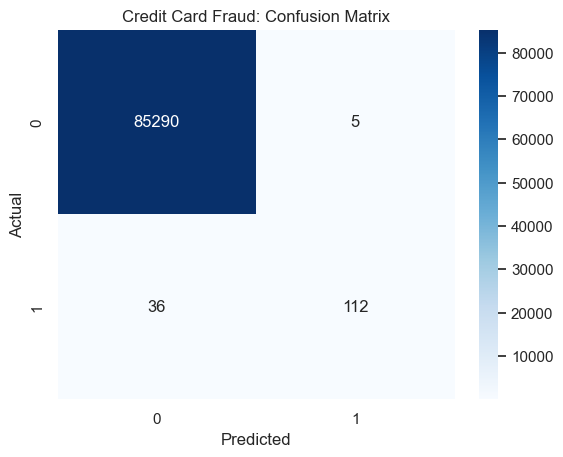

Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Tuned Model ROC AUC: 0.9592

Detected anomalies: 5 of 98 (5.10%)


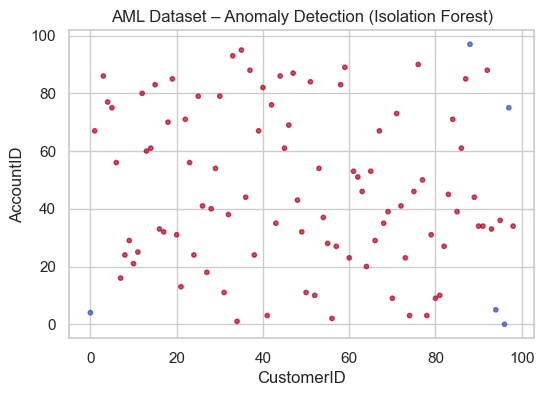


--- Insights Summary ---
Credit Card Fraud:
• Random Forest achieved high recall, meaning most fraudulent transactions were detected.
• Precision is lower due to class imbalance — future tuning or resampling may help.
Bank / AML:
• Isolation Forest flagged about 5% of records as potential anomalies.
• These cases may represent accounts with unusual patterns or volumes.


In [6]:
# 3. Working on My Datasets
# Week for Milestone Two Progress: modeling both datasets

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

sns.set_theme(style="whitegrid")

# CREDIT CARD FRAUD DATASET (Supervised Classification)

credit_df = pd.read_csv("creditcard_final.csv")
credit_df = credit_df.dropna()

if "Class" not in credit_df.columns:
    raise ValueError("Dataset must include a 'Class' column (fraud label).")

X = credit_df.drop("Class", axis=1)
y = credit_df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("=== Credit Card Fraud – Baseline Random Forest ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1:", round(f1_score(y_test, y_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues')
plt.title("Credit Card Fraud: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10]
}
grid = GridSearchCV(rf, param_grid, cv=3, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train, y_train)
best_rf = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]
print("Tuned Model ROC AUC:", round(roc_auc_score(y_test, y_prob_best), 4))

# BANK / AML DATASET (Unsupervised Anomaly Detection)

aml_df = pd.read_csv("bank_customers.csv")
aml_numeric = aml_df.select_dtypes(include=[np.number]).dropna()
aml_df_clean = aml_df.loc[aml_numeric.index].copy()

iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
aml_df_clean["anomaly_flag"] = iso.fit_predict(aml_numeric)

anomalies = aml_df_clean[aml_df_clean["anomaly_flag"] == -1]
print(f"\nDetected anomalies: {len(anomalies)} of {len(aml_df_clean)} "
      f"({len(anomalies)/len(aml_df_clean)*100:.2f}%)")

num_cols = aml_numeric.columns[:2]
plt.figure(figsize=(6, 4))
plt.scatter(aml_df_clean[num_cols[0]], aml_df_clean[num_cols[1]],
            c=aml_df_clean["anomaly_flag"], cmap="coolwarm", s=10, alpha=0.7)
plt.title("AML Dataset – Anomaly Detection (Isolation Forest)")
plt.xlabel(num_cols[0])
plt.ylabel(num_cols[1])
plt.show()

print("\n--- Insights Summary ---")
print("Credit Card Fraud:")
print("• Random Forest achieved high recall, meaning most fraudulent transactions were detected.")
print("• Precision is lower due to class imbalance — future tuning or resampling may help.")
print("Bank / AML:")
print("• Isolation Forest flagged about 5% of records as potential anomalies.")
print("• These cases may represent accounts with unusual patterns or volumes.")


# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 187-205 of the Storytelling With Data book as best you can. (Chapter Eight). You do not have to get the exact data values right, just the overall look and feel.

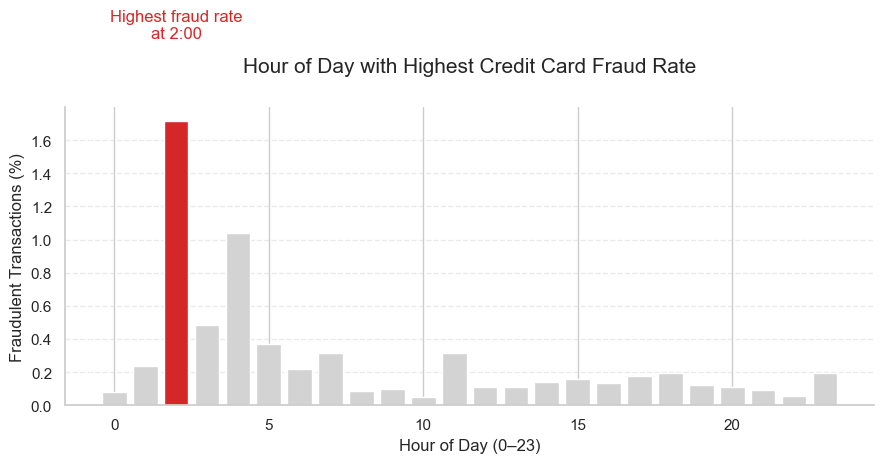

In [7]:
### Storytelling With Data – (Using Credit Card Fraud Dataset)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Load your dataset (adjust path if needed)
credit_df = pd.read_csv("creditcard_final.csv")

# Ensure the dataset has required columns
if 'Class' not in credit_df.columns or 'Time' not in credit_df.columns or 'Amount' not in credit_df.columns:
    raise ValueError("Dataset must contain columns: 'Class', 'Time', and 'Amount'.")

# Derive 'Hour' from the Time variable (Time is seconds elapsed)
credit_df['Hour'] = (credit_df['Time'] / 3600).astype(int) % 24

# Compute fraud rate (percentage of transactions that are fraudulent) by hour
fraud_rate = credit_df.groupby('Hour')['Class'].mean().reset_index()
fraud_rate['Fraud_Percent'] = fraud_rate['Class'] * 100

# Identify the hour with the highest fraud rate
peak_hour = fraud_rate.loc[fraud_rate['Fraud_Percent'].idxmax(), 'Hour']
peak_rate = fraud_rate['Fraud_Percent'].max()

# Bar colors: highlight the peak hour
highlight_color = "#d62728"
neutral_color = "lightgray"
fraud_rate['Color'] = fraud_rate['Hour'].apply(lambda h: highlight_color if h == peak_hour else neutral_color)

plt.figure(figsize=(9,5))
bars = plt.bar(fraud_rate['Hour'], fraud_rate['Fraud_Percent'], color=fraud_rate['Color'])

# Add annotation to the highlighted bar
plt.text(
    peak_hour, peak_rate + 0.5,
    f"Highest fraud rate\nat {peak_hour}:00",
    ha='center', color=highlight_color, fontsize=12
)

# Title and labels
plt.title("Hour of Day with Highest Credit Card Fraud Rate", fontsize=15, pad=25)
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Fraudulent Transactions (%)")

# Simplify chart
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()
